In [24]:
import random
import numpy as np
import pandas as pd
import torch

from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments
)

from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


In [25]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [26]:
dataset = load_dataset("emotion")
dataset["train"] = dataset["train"].shuffle(seed=SEED).select(range(2000))
dataset["validation"] = dataset["validation"].shuffle(seed=SEED).select(range(500))
dataset["test"] = dataset["test"].shuffle(seed=SEED).select(range(500))

print(dataset)

print("Train:", len(dataset["train"]))
print("Validation:", len(dataset["validation"]))
print("Test:", len(dataset["test"]))

labels = dataset["train"].features["label"].names
print("Classes:", labels)

print("Examples:")
for i in range(5):
    print(dataset["train"][i]["text"], "->", labels[dataset["train"][i]["label"]])

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 500
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 500
    })
})
Train: 2000
Validation: 500
Test: 500
Classes: ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']
Examples:
while cycling in the country -> fear
i had pocket qq and was feeling pretty confident lol -> joy
i am in no way complaining or whining or feeling ungrateful -> sadness
i feel a bit stressed because it feels like im supposed to do something all the time and that i should be reading now -> anger
i tell the people closest to me things that i am feeling and its as if they arent surprised because theyd known it all along -> surprise


In [27]:
"""
Классифицируем эмоции текста (6 классов: joy, sadness, anger, fear, love, surprise).
"""

'\nКлассифицируем эмоции текста (6 классов: joy, sadness, anger, fear, love, surprise).\n'

Классифицируем эмоции текста (6 классов: joy, sadness, anger, fear, love, surprise).

In [44]:
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

texts = [dataset["train"][i]["text"] for i in range(3)]

encodings = tokenizer(texts, padding=True, truncation=True)

for i, text in enumerate(texts):
    print("TEXT:", text)
    print("TOKENS:", tokenizer.tokenize(text))
    print("INPUT_IDS:", encodings["input_ids"][i])
    print("ATTENTION:", encodings["attention_mask"][i])
    print("WITH SPECIAL TOKENS:", tokenizer.convert_ids_to_tokens(encodings["input_ids"][i]))
    print()

print("PADDING EXAMPLE:")
for i in range(len(texts)):
    print(encodings["input_ids"][i])

TEXT: while cycling in the country
TOKENS: ['while', 'cycling', 'in', 'the', 'country']
INPUT_IDS: [101, 2096, 9670, 1999, 1996, 2406, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
ATTENTION: [1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
WITH SPECIAL TOKENS: ['[CLS]', 'while', 'cycling', 'in', 'the', 'country', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']

TEXT: i had pocket qq and was feeling pretty confident lol
TOKENS: ['i', 'had', 'pocket', 'q', '##q', 'and', 'was', 'feeling', 'pretty', 'confident', 'lo', '##l']
INPUT_IDS: [101, 1045, 2018, 4979, 1053, 4160, 1998, 2001, 3110, 3492, 9657, 8840, 2140, 102, 0, 0, 0]
ATTENTION: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0]
WITH SPECIAL TOKENS: ['[CLS]', 'i', 'had', 'pocket', 'q', '##q', 'and', 'was', 'feeling', 'pretty', 'confident', 'lo', '##l', '[SEP]', '[PAD]', '[PAD]', '[PAD]']

TEXT: i am in no way complaining or whining or feeling ungrateful
TOKENS: ['i', 'am', 'in', 'no', 'w

In [29]:
model = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=6
).to(device)

inputs = tokenizer(texts, return_tensors="pt", padding=True, truncation=True).to(device)

with torch.no_grad():
    outputs = model(**inputs)
    preds = torch.argmax(outputs.logits, dim=1)

for text, pred in zip(texts, preds):
    print(text, "->", labels[pred])

Loading weights: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████| 199/199 [00:00<00:00, 4716.64it/s]
BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch

while cycling in the country -> anger
i had pocket qq and was feeling pretty confident lol -> anger
i am in no way complaining or whining or feeling ungrateful -> anger


In [30]:
"""
Модель не обучена на эмоциях - предсказания неверные, случайные.
"""

'\nМодель не обучена на эмоциях - предсказания неверные, случайные.\n'

Модель не обучена на эмоциях - предсказания неверные, случайные.

In [31]:
def tokenize_function(example):
    return tokenizer(example["text"], truncation=True, padding="max_length", max_length=64)

tokenized_datasets = dataset.map(tokenize_function, batched=True)

tokenized_datasets = tokenized_datasets.rename_column("label", "labels")
tokenized_datasets.set_format("torch")

Map: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 500/500 [00:00<00:00, 16862.34 examples/s]


In [32]:
def compute_metrics(eval_pred):
    logits, labels_true = eval_pred
    preds = np.argmax(logits, axis=1)
    
    acc = accuracy_score(labels_true, preds)
    f1 = f1_score(labels_true, preds, average="macro")
    
    return {"accuracy": acc, "f1_macro": f1}

In [36]:
model = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=6
).to(device)

training_args = TrainingArguments(
    output_dir="./results",
    save_strategy="no",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=1,
    seed=SEED,
    logging_steps=100,
    report_to="none",
    disable_tqdm=True,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    compute_metrics=compute_metrics,
)

Loading weights: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████| 199/199 [00:00<00:00, 5134.10it/s]
BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch

In [37]:
trainer.train()

D:\Project_university\Artificial-Intelligence-Engineering\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


{'loss': '1.566', 'grad_norm': '20.02', 'learning_rate': '1.208e-05', 'epoch': '0.4'}
{'loss': '1.217', 'grad_norm': '12.71', 'learning_rate': '4.08e-06', 'epoch': '0.8'}
{'train_runtime': '475.3', 'train_samples_per_second': '4.208', 'train_steps_per_second': '0.526', 'train_loss': '1.347', 'epoch': '1'}


TrainOutput(global_step=250, training_loss=1.3465048828125, metrics={'train_runtime': 475.3174, 'train_samples_per_second': 4.208, 'train_steps_per_second': 0.526, 'train_loss': 1.3465048828125, 'epoch': 1.0})

In [38]:
test_results = trainer.evaluate(tokenized_datasets["test"])
print(test_results)

{'eval_loss': '1.017', 'eval_accuracy': '0.626', 'eval_f1_macro': '0.2491', 'eval_runtime': '27.24', 'eval_samples_per_second': '18.36', 'eval_steps_per_second': '2.313', 'epoch': '1'}
{'eval_loss': 1.0173141956329346, 'eval_accuracy': 0.626, 'eval_f1_macro': 0.24908832754735366, 'eval_runtime': 27.2381, 'eval_samples_per_second': 18.357, 'eval_steps_per_second': 2.313, 'epoch': 1.0}


In [39]:
preds_output = trainer.predict(tokenized_datasets["test"])

logits = preds_output.predictions
y_pred = np.argmax(logits, axis=1)
y_true = preds_output.label_ids

D:\Project_university\Artificial-Intelligence-Engineering\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


In [40]:
acc = accuracy_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred, average="macro")

print("Accuracy:", acc)
print("F1_macro:", f1)

Accuracy: 0.626
F1_macro: 0.24908832754735366


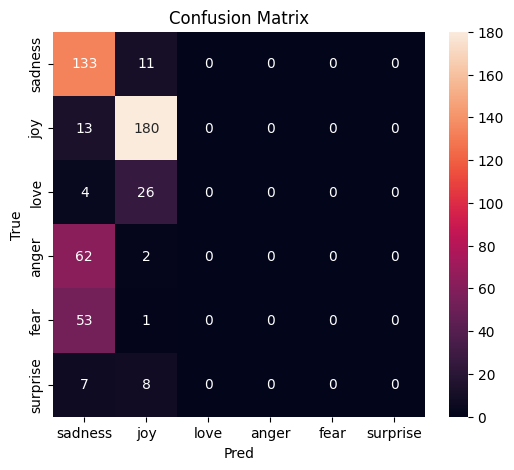

In [41]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=labels, yticklabels=labels)
plt.xlabel("Pred")
plt.ylabel("True")
plt.title("Confusion Matrix")

plt.savefig("./artifacts/confusion_matrix.png")
plt.show()

In [42]:
df = pd.DataFrame({
    "text": dataset["test"]["text"],
    "true_label": [labels[i] for i in y_true],
    "pred_label": [labels[i] for i in y_pred],
    "confidence": np.max(torch.softmax(torch.tensor(logits), dim=1).numpy(), axis=1)
})

df_sample = df.sample(10, random_state=SEED)
print(df_sample)

df_sample.to_csv("./artifacts/sample_predictions.csv", index=False)

                                                  text true_label pred_label  \
361  i told my fiance how i am feeling so angry and...      anger    sadness   
73   i feel i m handling it well and i m enjoying i...        joy        joy   
374  i feel these days living in fears just another...        joy        joy   
155  im just now realizing i didnt have a diet coke...        joy        joy   
104              im feeling rather angsty and listless    sadness    sadness   
394                   i got off the phone feeling numb    sadness    sadness   
377    i feel last time ure the one that feel paranoid       fear    sadness   
124  i feel slytherin is my house slytherin is for ...        joy        joy   
68   i feel completely rude with not keeping up wit...      anger    sadness   
450  i feel like most teams would have appeased jac...      anger    sadness   

     confidence  
361    0.474885  
73     0.749274  
374    0.371113  
155    0.775578  
104    0.483734  
394    0.51

в первом примере в тексте явно есть слово angry, но модель всё равно предсказывает sadness. Это может происходить из-за: контекста (возможно, есть элементы сожаления или подавленности) или модель не доучилась (1 эпоха)
в 7 примере слово paranoid связано с тревогой/страхом, но: модель может не ассоциировать его чётко с классом fear
в 9 примере эмоция выражена не напрямую. Фраза "feel rude" может интерпретироваться как: вина / сожаление - ближе к sadness или раздражение - anger
